In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Dataset.csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


Text(0.5, 1.0, 'Average Cost of two per city,Top 5')

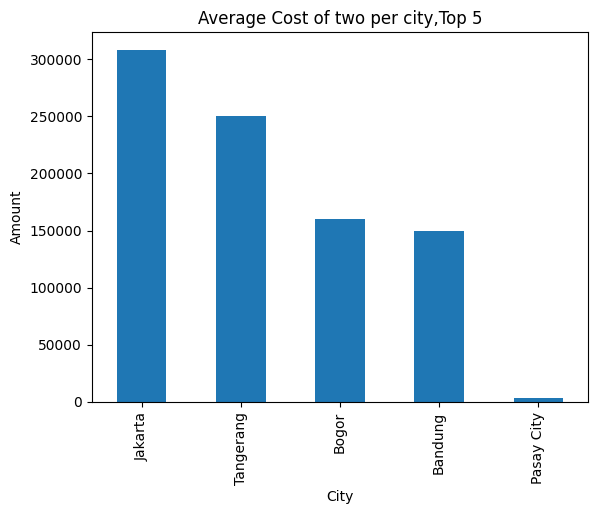

In [7]:
df.groupby("City")["Average Cost for two"].mean().sort_values(ascending=False).head().plot(kind='bar')
plt.xlabel("City")
plt.ylabel("Amount")
plt.title("Average Cost of two per city,Top 5")

In [8]:
data=df.groupby('Cuisines')['Votes'].sum().reset_index()
data

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
2,"Afghani, North Indian",0
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373
...,...,...
1820,"Western, Asian, Cafe",259
1821,"Western, Fusion, Fast Food",32
1822,World Cuisine,95
1823,"World Cuisine, Mexican, Italian",115


In [9]:
data=data[data['Votes']!=0]
data

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373
5,"African, Portuguese",265
...,...,...
1820,"Western, Asian, Cafe",259
1821,"Western, Fusion, Fast Food",32
1822,World Cuisine,95
1823,"World Cuisine, Mexican, Italian",115


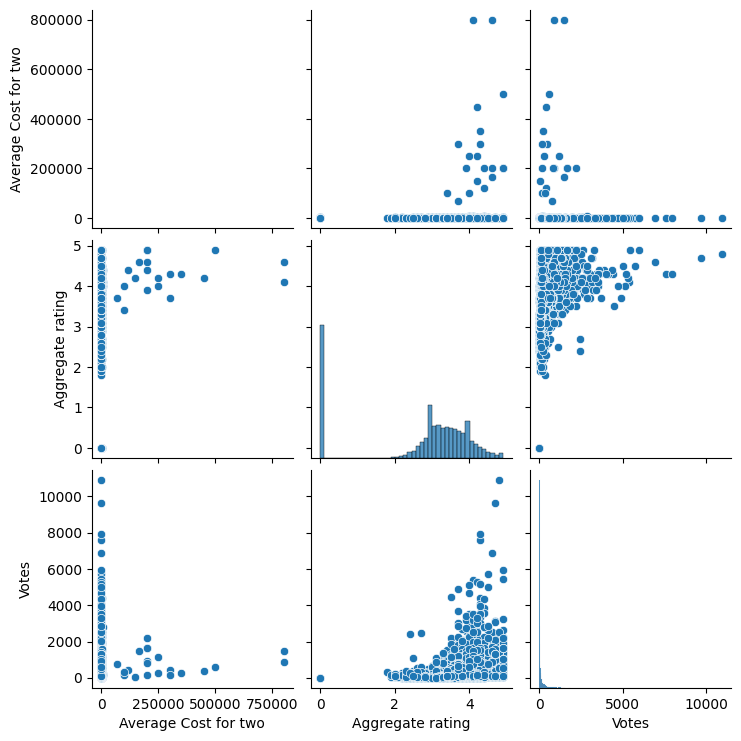

In [10]:
sns.pairplot(df[["Average Cost for two","Aggregate rating","Votes"]])

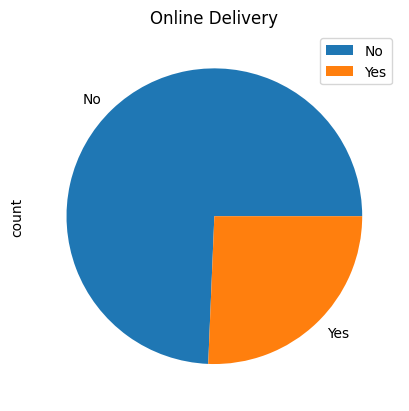

In [11]:
df['Has Online delivery'].value_counts().plot(kind='pie')
plt.title('Online Delivery')
plt.legend()
plt.show()

In [12]:
df[['Aggregate rating','Rating text']].sort_values(by='Aggregate rating',ascending=True)

,Aggregate rating,Rating text
2710,0.0,Not rated
7292,0.0,Not rated
7291,0.0,Not rated
7290,0.0,Not rated
1502,0.0,Not rated
...,...,...
175,4.9,Excellent
9524,4.9,Excellent
8,4.9,Excellent
9538,4.9,Excellent


In [13]:
df=df[df['Rating text']!='Not rated']
df.shape

(7403, 21)

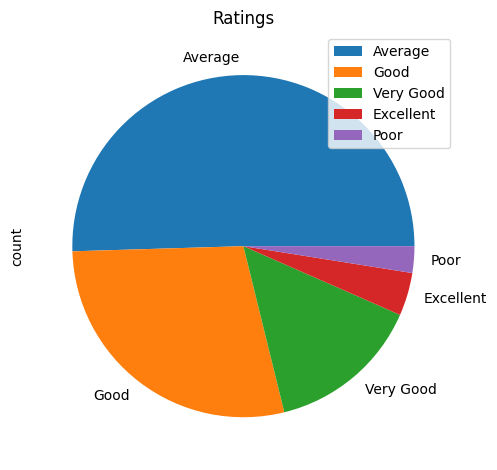

In [14]:
df['Rating text'].value_counts().plot(kind='pie')
plt.title('Ratings')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
X=df[['Average Cost for two','Has Table booking','Has Online delivery','Price range']]

In [16]:
Y=df['Aggregate rating']

In [17]:
X

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,Yes,No,3
1,1200,Yes,No,3
2,4000,Yes,No,4
3,1500,No,No,4
4,1500,Yes,No,4
...,...,...,...,...
9546,80,No,No,3
9547,105,No,No,3
9548,170,No,No,4
9549,120,No,No,4


In [18]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [19]:
le=LabelEncoder()
X['Has Table booking']=le.fit_transform(X['Has Table booking'])
X

/tmp/ipython-input-2834314249.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Table booking']=le.fit_transform(X['Has Table booking'])


,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,1,No,3
1,1200,1,No,3
2,4000,1,No,4
3,1500,0,No,4
4,1500,1,No,4
...,...,...,...,...
9546,80,0,No,3
9547,105,0,No,3
9548,170,0,No,4
9549,120,0,No,4


In [20]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [21]:
X['Has Online delivery']=le.fit_transform(X['Has Online delivery'])
X

/tmp/ipython-input-1756510360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Online delivery']=le.fit_transform(X['Has Online delivery'])


,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,1,0,3
1,1200,1,0,3
2,4000,1,0,4
3,1500,0,0,4
4,1500,1,0,4
...,...,...,...,...
9546,80,0,0,3
9547,105,0,0,3
9548,170,0,0,4
9549,120,0,0,4


In [22]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [23]:
sc=StandardScaler()

In [24]:
X=sc.fit_transform(X)
X

array([[-0.0190367 ,  2.37978283, -0.68302371,  1.10671644],
       [-0.0135729 ,  2.37978283, -0.68302371,  1.10671644],
       [ 0.13941344,  2.37978283, -0.68302371,  2.18135204],
       ...,
       [-0.06985002, -0.42020641, -0.68302371,  2.18135204],
       [-0.07258191, -0.42020641, -0.68302371,  2.18135204],
       [-0.07613338, -0.42020641, -0.68302371,  0.03208084]])

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=3)

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [27]:
def modelResults(predictions):
  print("Mean absolute error of model is {}".format(mean_absolute_error(Y_test,predictions)))
  print("Root mean squared error of model is {}".format(np.sqrt(mean_squared_error(Y_test,predictions))))

In [28]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [29]:
lr.fit(X_train,Y_train)

LinearRegression()

In [30]:
predictions=lr.predict(X_test)

In [31]:
modelResults(predictions)

Mean absolute error of model is 0.38488089888553095
Root mean squared error of model is 0.4866147172599697


In [32]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [33]:
svr=SVR()

In [37]:
param_gridsvr={'C':[0.1,0.5],'kernel':['linear','poly'],'degree':[2]}

In [38]:
gridsvr=GridSearchCV(svr,param_gridsvr )

In [39]:
gridsvr.fit(X_train,Y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 0.5], 'degree': [2],
                         'kernel': ['linear', 'poly']})

In [40]:
predictions=gridsvr.predict(X_test)

In [41]:
modelResults(predictions)

Mean absolute error of model is 0.3843463681604009
Root mean squared error of model is 0.4908246825155683


In [42]:
from sklearn.tree import DecisionTreeRegressor

In [53]:
param_griddtr={
    'max_depth':[10,30],
    'min_samples_leaf':[1,2],
    'min_samples_split':[2,5]
}

In [44]:
dtr=DecisionTreeRegressor()

In [54]:
gridTree=GridSearchCV(estimator=dtr,param_grid=param_griddtr)

In [55]:
gridTree.fit(X_train,Y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [10, 30], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5]})

In [48]:
predictions=gridTree.predict(X_test)

In [49]:
modelResults(predictions)

Mean absolute error of model is 0.35819993105662323
Root mean squared error of model is 0.45786850857634237


In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf=RandomForestRegressor()

In [56]:
param_gridrfr={
    'max_depth':[5,15],
    'n_estimators':[2,5,10]
}

In [57]:
gridrfr=GridSearchCV(rf,param_gridrfr)

In [58]:
gridrfr.fit(X_train,Y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 15], 'n_estimators': [2, 5, 10]})

In [59]:
predictions=gridrfr.predict(X_test)

In [60]:
modelResults(predictions)

Mean absolute error of model is 0.35196403495864603
Root mean squared error of model is 0.452559037994511


In [62]:
import joblib
joblib.dump(gridrfr,'mlmodel.pkl')
joblib.dump(sc,'scaler.pkl')

['scaler.pkl']